<a href="https://colab.research.google.com/github/DarshiniMahesh/AI-Practice/blob/main/Digit_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Step 1: Import libraries
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [9]:
# Step 2: Set Training Flag
train_new_model = True

# Step 3: Load Dataset
if train_new_model:
    mnist = tf.keras.datasets.mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    # Step 4: Normalize Data
    x_train = tf.keras.utils.normalize(x_train, axis=1)
    x_test = tf.keras.utils.normalize(x_test, axis=1)

    # Step 5: Build Model
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(units=128, activation=tf.nn.relu))
    model.add(tf.keras.layers.Dense(units=128, activation=tf.nn.relu))
    model.add(tf.keras.layers.Dense(units=10, activation=tf.nn.softmax))

    # Step 6: Compile Model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Step 7: Train Model
    model.fit(x_train, y_train, epochs=3)

    # Step 8: Evaluate Model
    val_loss, val_acc = model.evaluate(x_test, y_test)

    # Step 9: Print Results
    print(val_loss)
    print(val_acc)

    # Step 10: Save Model (FIXED)
    model.save('handwritten_digits.keras')

# Step 11: Load Model
else:
    model = tf.keras.models.load_model('handwritten_digits.keras')

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9219 - loss: 0.2642
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9664 - loss: 0.1081
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9760 - loss: 0.0763
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9675 - loss: 0.1058
0.10580199211835861
0.9674999713897705


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
digits/digit0.png → Predicted: 0


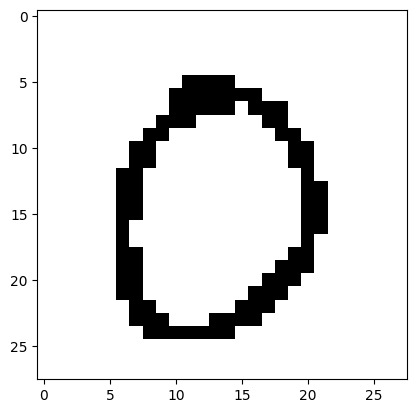

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
digits/digit1.png → Predicted: 1


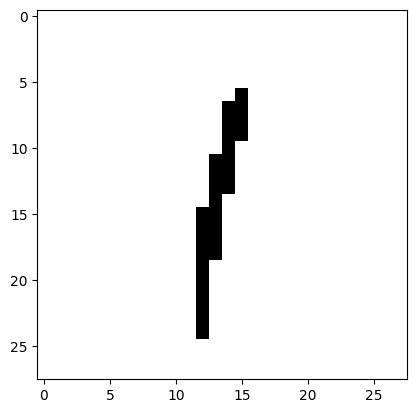

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
digits/digit2.png → Predicted: 2


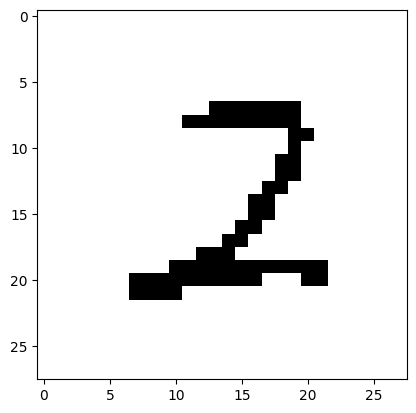

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
digits/digit3.png → Predicted: 3


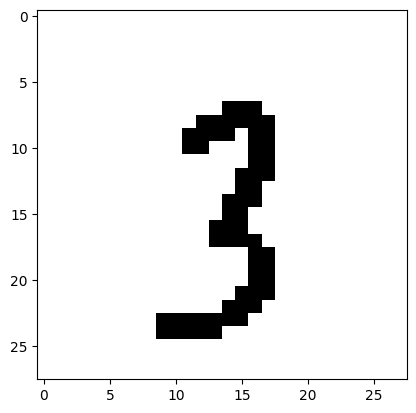

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
digits/digit4.png → Predicted: 4


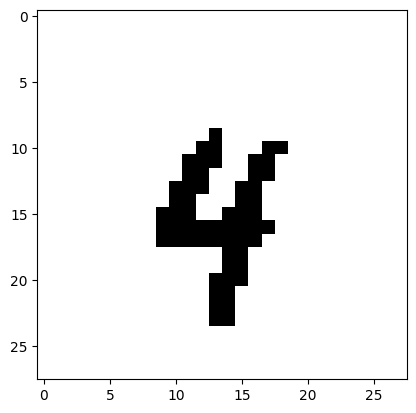

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
digits/digit5.png → Predicted: 3


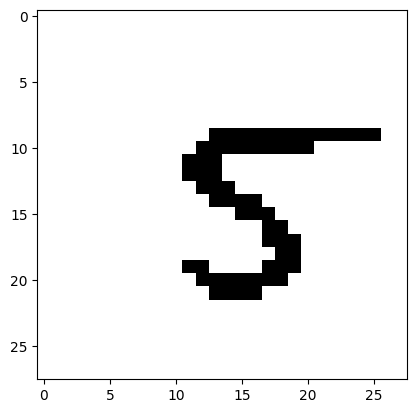

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
digits/digit6.png → Predicted: 6


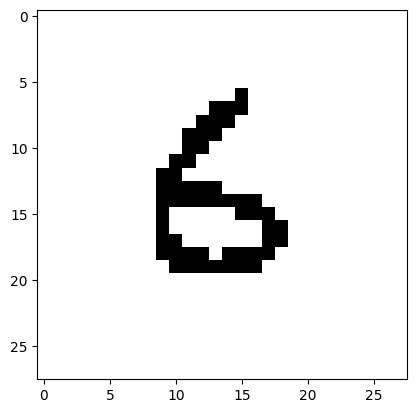

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
digits/digit7.png → Predicted: 7


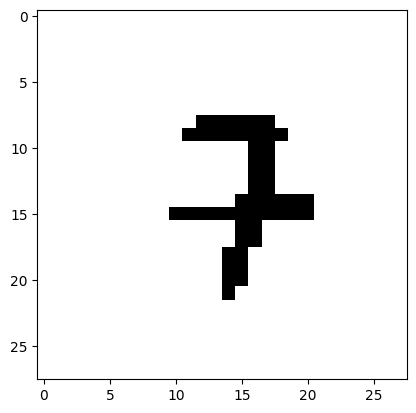

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
digits/digit8.png → Predicted: 8


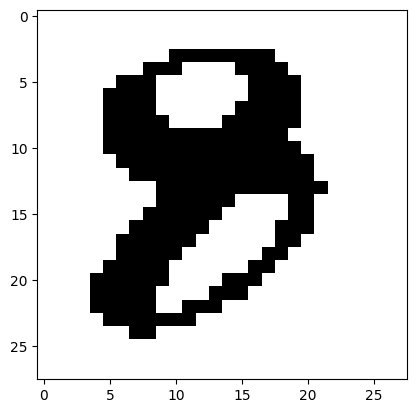

In [19]:
image_number = 0  # since your files start from digit0.png

while os.path.isfile(f'digits/digit{image_number}.png'):
    try:
        path = f'digits/digit{image_number}.png'

        # Step 1: Read as grayscale
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Failed to load {path}")
            image_number += 1
            continue

        # Step 2: Resize to 28x28
        img = cv2.resize(img, (28, 28))

        # Step 3: Invert colors (MNIST format)
        img = cv2.bitwise_not(img)

        # Step 4: Threshold (IMPORTANT)
        _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

        # Step 5: Normalize
        img = img / 255.0

        # Step 6: Reshape
        img = np.array([img])

        # Step 7: Predict
        prediction = model.predict(img)

        print(f"{path} → Predicted: {np.argmax(prediction)}")

        plt.imshow(img[0], cmap=plt.cm.binary)
        plt.show()

        image_number += 1

    except Exception as e:
        print(f"Error with {path}: {e}")
        image_number += 1